In [1]:
# for it to run first open and terminal in a window aside of this and clicking in the '+' button and run a "pip install rubin_sim" in case this requirement isn't already satisfied

In [2]:
import numpy as np
import pandas as pd
import healpy as hp
import os
import tarfile
import matplotlib.pylab as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from rubin_scheduler.utils import ra_dec2_hpid
from rubin_scheduler.scheduler.utils import CurrentAreaMap

In [3]:
# Dynamically find the user's home directory (works for any colleague)
HOME_DIR = os.path.expanduser("~")
BASE_DATA_DIR = os.path.join(HOME_DIR, "rubin_sim_data")
DUST_MAP_PATH = os.path.join(BASE_DATA_DIR, "maps", "DustMaps", "dust_nside_64.npz")
TAR_PATH = os.path.join(BASE_DATA_DIR, "maps_2022_2_28.tgz")

print("Checking environment for reproducibility...")

if not os.path.exists(DUST_MAP_PATH):
    print("-> Dust map not found. Downloading physical dust maps (this takes a moment)...")
    os.makedirs(BASE_DATA_DIR, exist_ok=True)
    
    # We use the working part of the Rubin downloader to get the maps
    os.system("rs_download_data -d maps --tdqm_disable")
    
    if os.path.exists(TAR_PATH):
        print("-> Extracting maps...")
        with tarfile.open(TAR_PATH, "r:gz") as tar:
            tar.extractall(path=BASE_DATA_DIR)
        print("-> Setup complete! Dust map is ready.")
else:
    print("-> Environment is ready! Dust map found.")

Checking environment for reproducibility...
-> Environment is ready! Dust map found.


Loading sources from wu_shen_RA_DEC_columns.csv...
Generating WFD footprint based on physical Dust limits (E(B-V) < 0.2)...
Cross-matching...

--- RESULTS ---
Total input catalog: 750414
Total inside LSST (WFD+DDFs): 103839
Total inside any DDF: 1813
-> Saved categorized DDF targets to 'sources_inside_ddfs_categorized.txt'
-> Plot saved as 'lsst_footprint_ddfs_clean.png'.



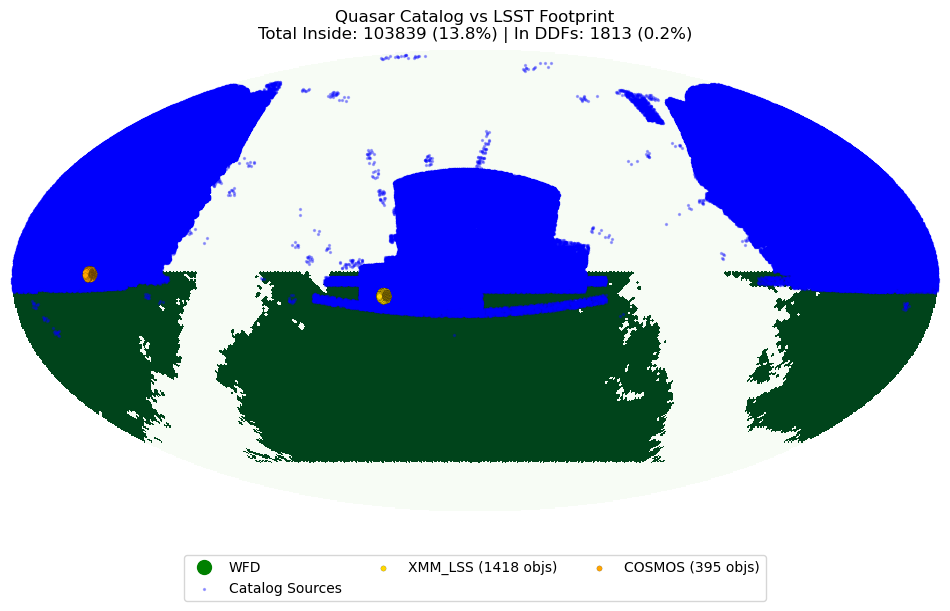

In [5]:
# ============================================================================
# LSST DUST-ACCURATE FOOTPRINT & MULTI-DDF EXTRACTOR
# Uses the physical SFD E(B-V) map to construct the WFD, cross-matches 
# all targets, and dynamically plots/exports sources found in any DDF.
# ============================================================================

# --- CONFIGURATION ---
CSV_META_PATH = "wu_shen_RA_DEC_columns.csv" 
NSIDE = 64

# Output files
OUT_TXT_ALL_LSST = "sources_inside_all_lsst.txt"
OUT_TXT_DDFS = "sources_inside_ddfs_categorized.txt"
OUT_PLOT = "lsst_footprint_ddfs_clean.png"

# Official LSST Deep Drilling Fields (RA, DEC) in degrees
LSST_DDFS = {
    'ELAIS_S1': (9.45, -44.0),
    'XMM_LSS': (35.708333, -4.75),
    'ECDFS': (53.125, -28.1),
    'COSMOS': (150.1, 2.1819),
    'EDFS': (61.0, -48.0) 
}
LSST_FOV_RADIUS = 1.75 * u.deg # ~9.6 sq deg

# Colors for dynamically plotting DDFs (if you want to distinguish them)
DDF_COLORS = ['gold', 'orange', 'cyan', 'magenta', 'red']

def run_clean_crossmatch():
    if not os.path.exists(CSV_META_PATH):
        print(f"Error: '{CSV_META_PATH}' not found.")
        return
        
    if not os.path.exists(DUST_MAP_PATH):
        print(f"Error: SFD Dust map not found at {DUST_MAP_PATH}.")
        return

    # 1. Load catalog
    print(f"Loading sources from {CSV_META_PATH}...")
    meta = pd.read_csv(CSV_META_PATH)
    ra_sample = meta['RA'].values
    dec_sample = meta['DEC'].values
    total_sources = len(ra_sample)
    
    sample_coords = SkyCoord(ra=ra_sample*u.deg, dec=dec_sample*u.deg, frame='icrs')

    # 2. Build the Official WFD Map using SFD Dust Data
    print("Generating WFD footprint based on physical Dust limits (E(B-V) < 0.2)...")
    with np.load(DUST_MAP_PATH) as data:
        ebv_map = data["ebvMap"] 
        
    npix = hp.nside2npix(NSIDE)
    wfd_map = np.zeros(npix)
    
    _, dec_pix = hp.pix2ang(NSIDE, np.arange(npix), lonlat=True)
    in_wfd_dust = (dec_pix >= -62.5) & (dec_pix <= 2.8) & (ebv_map < 0.2)
    wfd_map[in_wfd_dust] = 1.0

    # 3. Cross-match: WFD
    print("Cross-matching...")
    pixel_ids = hp.ang2pix(NSIDE, ra_sample, dec_sample, lonlat=True)
    inside_wfd = wfd_map[pixel_ids] > 0
    
    # 4. Cross-match: DDFs (Categorizing them)
    # Array to store the name of the DDF each source belongs to (empty string if none)
    ddf_labels = np.full(total_sources, "", dtype=object)
    
    for name, (ddf_ra, ddf_dec) in LSST_DDFS.items():
        ddf_coord = SkyCoord(ra=ddf_ra*u.deg, dec=ddf_dec*u.deg)
        separations = sample_coords.separation(ddf_coord)
        in_this_ddf = separations <= LSST_FOV_RADIUS
        
        # Assign the DDF name to the corresponding sources
        ddf_labels[in_this_ddf] = name

    # Boolean mask for sources that fell into ANY DDF
    inside_any_ddf = ddf_labels != ""
    inside_all_lsst = inside_wfd | inside_any_ddf
    
    n_all_lsst = np.sum(inside_all_lsst)
    n_any_ddf = np.sum(inside_any_ddf)

    print(f"\n--- RESULTS ---")
    print(f"Total input catalog: {total_sources}")
    print(f"Total inside LSST (WFD+DDFs): {n_all_lsst}")
    print(f"Total inside any DDF: {n_any_ddf}")
    
    # 5. Export TXT 1: All LSST footprint sources
    if n_all_lsst > 0:
        with open(OUT_TXT_ALL_LSST, 'w') as f:
            f.write("# RA DEC\n")
            for ra, dec in zip(ra_sample[inside_all_lsst], dec_sample[inside_all_lsst]):
                f.write(f"{ra:.7f} {dec:.7f}\n")
                
    # 6. Export TXT 2: DDF sources with specific column labels
    if n_any_ddf > 0:
        with open(OUT_TXT_DDFS, 'w') as f:
            f.write(f"# RA DEC DDF_NAME\n")
            for ra, dec, label in zip(ra_sample[inside_any_ddf], dec_sample[inside_any_ddf], ddf_labels[inside_any_ddf]):
                f.write(f"{ra:.7f} {dec:.7f} {label}\n")
        print(f"-> Saved categorized DDF targets to '{OUT_TXT_DDFS}'")

    # 7. Visualization
    plt.figure(figsize=(12, 7))
    p1 = (n_all_lsst/total_sources)*100
    p2 = (n_any_ddf/total_sources)*100
    title_str = f'Quasar Catalog vs LSST Footprint\nTotal Inside: {n_all_lsst} ({p1:.1f}%) | In DDFs: {n_any_ddf} ({p2:.1f}%)'
    
    # Plot the WFD background
    hp.mollview(wfd_map, title=title_str, cmap="Greens", cbar=False, hold=True)
    # Proxy artist: invisible square to force "WFD" into the legend
    plt.plot([], [], marker='o', color='green', ls='none', markersize=10, label='WFD')
    # Plot ALL sample sources (Subtle Blue)
    hp.projscatter(ra_sample, dec_sample, lonlat=True, s=2, 
                   color='blue', alpha=0.3, label="Catalog Sources")

    # Plot sources inside DDFs dynamically (No explicit stars anymore)
    color_idx = 0
    for name in LSST_DDFS.keys():
        mask = ddf_labels == name
        matches = np.sum(mask)
        
        # Only plot and add to legend if the DDF actually contains sources
        if matches > 0:
            hp.projscatter(ra_sample[mask], dec_sample[mask], 
                           lonlat=True, s=15, color=DDF_COLORS[color_idx % len(DDF_COLORS)], 
                           edgecolor='black', linewidth=0.1, 
                           label=f"{name} ({matches} objs)")
            color_idx += 1

    # Adjust legend position to accommodate dynamic items cleanly
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=10)
    plt.savefig(OUT_PLOT, dpi=300, bbox_inches='tight')
    print(f"-> Plot saved as '{OUT_PLOT}'.\n")
    plt.show()

if __name__ == "__main__":
    run_clean_crossmatch()